# Group-Level Functional Connectivity Comparison

## Goal

This notebook extends the single-subject connectivity pipeline to multiple participants across diagnostic groups.

The goal is to compute average functional connectivity matrices for each group and compare psychiatric groups against healthy controls.

## Groups

- Healthy controls
- Schizophrenia
- Bipolar disorder
- ADHD

## Pipeline

1. Load participant metadata.
2. Select a small subset of participants from each diagnostic group.
3. Build a functional connectivity matrix for each participant.
4. Compute group-average connectivity matrices.
5. Visualize group differences.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nilearn import plotting

In [2]:
PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.connectivity import build_subject_connectivity_matrix

In [3]:
participants_url = "https://s3.amazonaws.com/openneuro/ds000030/ds000030_R1.0.4/uncompressed/participants.tsv"

participants = pd.read_csv(participants_url, sep="\t")

participants.head()

,participant_id,diagnosis,age,gender,bart,bht,dwi,pamenc,pamret,rest,scap,stopsignal,T1w,taskswitch,ScannerSerialNumber
0,sub-10159,CONTROL,30,F,1.0,NaN,1.0,NaN,NaN,1.0,1.0,1.0,1.0,1.0,35343.0
1,sub-10171,CONTROL,24,M,1.0,1.0,1.0,NaN,NaN,1.0,1.0,1.0,1.0,1.0,35343.0
2,sub-10189,CONTROL,49,M,1.0,NaN,1.0,NaN,NaN,1.0,1.0,1.0,1.0,1.0,35343.0
3,sub-10193,CONTROL,40,M,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,35343.0
4,sub-10206,CONTROL,21,M,1.0,NaN,1.0,NaN,NaN,1.0,1.0,1.0,1.0,1.0,35343.0


In [4]:
participants["diagnosis"].value_counts()

diagnosis
CONTROL    130
SCHZ        50
BIPOLAR     49
ADHD        43
Name: count, dtype: int64

In [5]:
participants_with_rest = participants[participants["rest"] == 1].copy()

participants_with_rest["diagnosis"].value_counts()

diagnosis
CONTROL    127
SCHZ        50
BIPOLAR     49
ADHD        42
Name: count, dtype: int64

In [6]:
N_PER_GROUP = 2

sample_parts = []

for diagnosis, group in participants_with_rest.groupby("diagnosis"):
    n = min(N_PER_GROUP, len(group))
    sampled_group = group.sample(n=n, random_state=42)
    sample_parts.append(sampled_group)

sample_participants = pd.concat(sample_parts).reset_index(drop=True)

sample_participants[["participant_id", "diagnosis", "age", "gender", "rest"]]

,participant_id,diagnosis,age,gender,rest
0,sub-70060,ADHD,21,M,1.0
1,sub-70035,ADHD,49,F,1.0
2,sub-60022,BIPOLAR,47,F,1.0
3,sub-60080,BIPOLAR,29,M,1.0
4,sub-10347,CONTROL,25,F,1.0
5,sub-11090,CONTROL,24,M,1.0
6,sub-50023,SCHZ,49,F,1.0
7,sub-50066,SCHZ,33,M,1.0


In [7]:
results = []
matrices = {}

for _, row in sample_participants.iterrows():
    subject_id = row["participant_id"]
    diagnosis = row["diagnosis"]
    
    print(f"Processing {subject_id} | diagnosis: {diagnosis}")
    
    try:
        result = build_subject_connectivity_matrix(subject_id)
        
        matrix_path = result["npy_path"]
        matrix = np.load(matrix_path)
        
        matrices[subject_id] = matrix
        
        results.append({
            "participant_id": subject_id,
            "diagnosis": diagnosis,
            "time_series_shape": result["time_series_shape"],
            "matrix_shape": result["matrix_shape"],
            "status": "success"
        })
        
    except Exception as error:
        print(f"Failed for {subject_id}: {error}")
        
        results.append({
            "participant_id": subject_id,
            "diagnosis": diagnosis,
            "time_series_shape": None,
            "matrix_shape": None,
            "status": "failed"
        })

results_df = pd.DataFrame(results)

results_df

Processing sub-70060 | diagnosis: ADHD
File already exists: C:\Users\vi\psychiatric-brain-connectivity-analysis\data\raw\sub-70060\func\sub-70060_task-rest_bold_space-MNI152NLin2009cAsym_preproc.nii.gz
[fetch_atlas_harvard_oxford] Dataset found in C:\Users\vi\nilearn_data\fsl
Processing sub-70035 | diagnosis: ADHD
Trying download from: https://s3.amazonaws.com/openneuro/ds000030/ds000030_R1.0.4/uncompressed/derivatives/fmriprep/sub-70035/func/sub-70035_task-rest_bold_space-MNI152NLin2009cAsym_preproc.nii.gz
Failed: HTTP Error 404: Not Found
Trying download from: https://s3.amazonaws.com/openneuro/ds000030/ds000030_R1.0.5/uncompressed/derivatives/fmriprep/sub-70035/func/sub-70035_task-rest_bold_space-MNI152NLin2009cAsym_preproc.nii.gz
Failed: HTTP Error 404: Not Found
Failed for sub-70035: Could not download file for sub-70035. Last error: HTTP Error 404: Not Found
Processing sub-60022 | diagnosis: BIPOLAR
File already exists: C:\Users\vi\psychiatric-brain-connectivity-analysis\data\raw

,participant_id,diagnosis,time_series_shape,matrix_shape,status
0,sub-70060,ADHD,"(152, 48)","(48, 48)",success
1,sub-70035,ADHD,None,None,failed
2,sub-60022,BIPOLAR,"(152, 48)","(48, 48)",success
3,sub-60080,BIPOLAR,"(152, 48)","(48, 48)",success
4,sub-10347,CONTROL,"(152, 48)","(48, 48)",success
5,sub-11090,CONTROL,"(152, 48)","(48, 48)",success
6,sub-50023,SCHZ,"(152, 48)","(48, 48)",success
7,sub-50066,SCHZ,"(152, 48)","(48, 48)",success


In [8]:
successful_subjects = results_df[results_df["status"] == "success"].copy()

successful_subjects

,participant_id,diagnosis,time_series_shape,matrix_shape,status
0,sub-70060,ADHD,"(152, 48)","(48, 48)",success
2,sub-60022,BIPOLAR,"(152, 48)","(48, 48)",success
3,sub-60080,BIPOLAR,"(152, 48)","(48, 48)",success
4,sub-10347,CONTROL,"(152, 48)","(48, 48)",success
5,sub-11090,CONTROL,"(152, 48)","(48, 48)",success
6,sub-50023,SCHZ,"(152, 48)","(48, 48)",success
7,sub-50066,SCHZ,"(152, 48)","(48, 48)",success


In [9]:
group_average_matrices = {}

for diagnosis, group_df in successful_subjects.groupby("diagnosis"):
    subject_ids = group_df["participant_id"].tolist()
    
    group_matrices = [matrices[subject_id] for subject_id in subject_ids]
    
    group_average_matrices[diagnosis] = np.mean(group_matrices, axis=0)
    
    print(f"{diagnosis}: {len(group_matrices)} subject(s), matrix shape {group_average_matrices[diagnosis].shape}")

ADHD: 1 subject(s), matrix shape (48, 48)
BIPOLAR: 2 subject(s), matrix shape (48, 48)
CONTROL: 2 subject(s), matrix shape (48, 48)
SCHZ: 2 subject(s), matrix shape (48, 48)


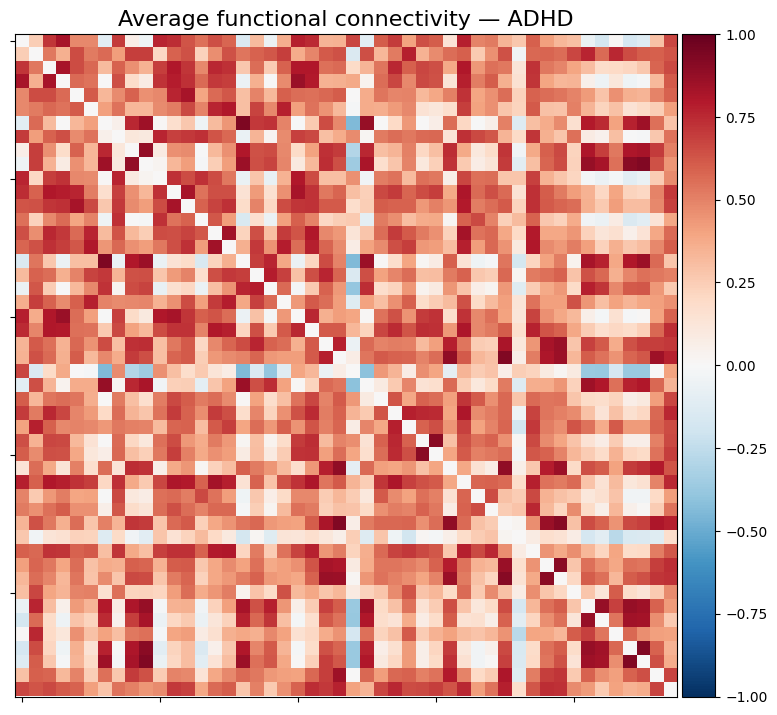

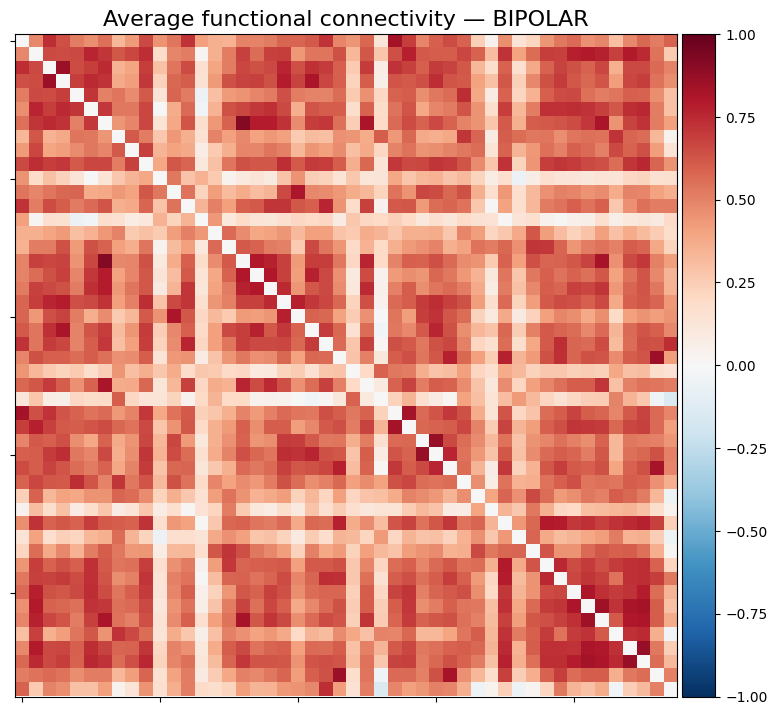

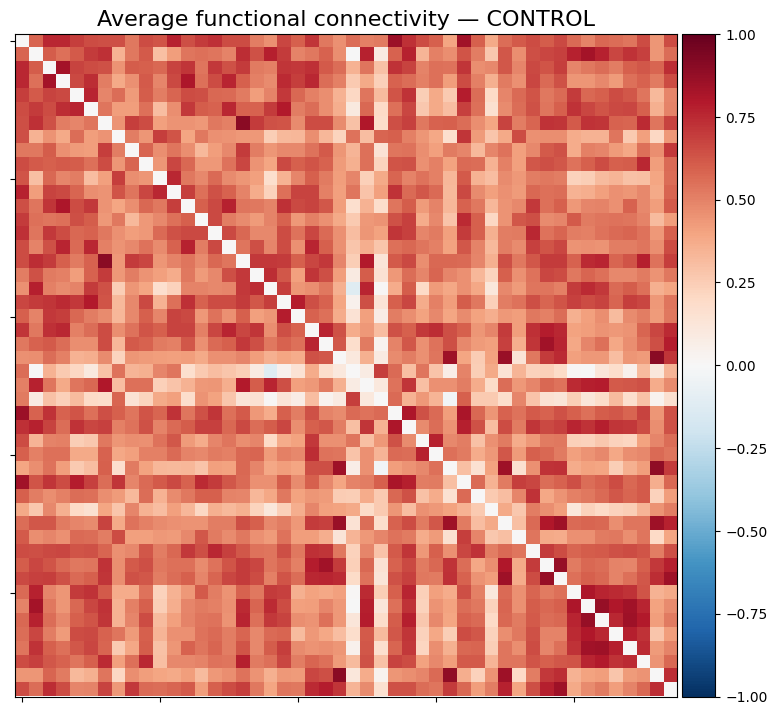

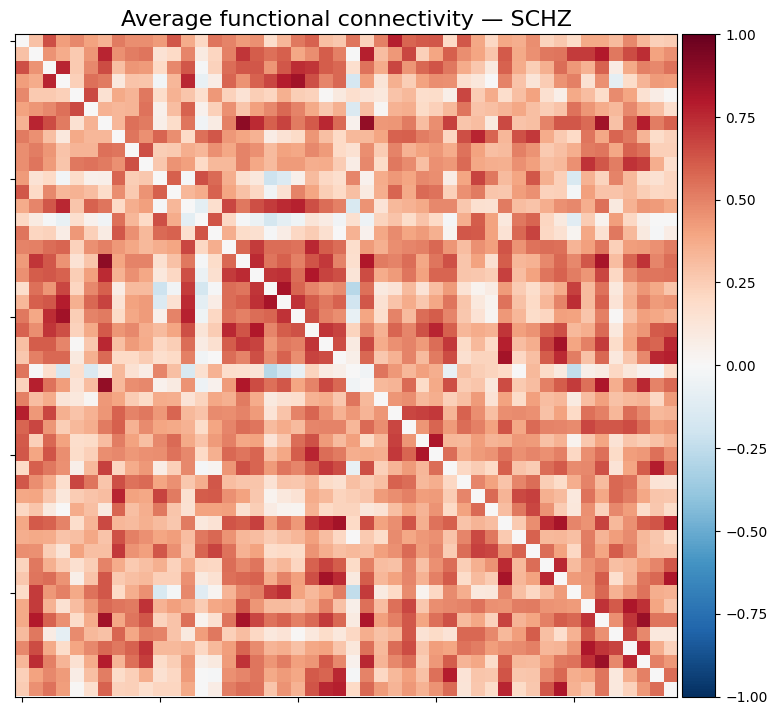

In [10]:
for diagnosis, matrix in group_average_matrices.items():
    plotting.plot_matrix(
        matrix,
        figure=(8, 7),
        vmin=-1,
        vmax=1,
        reorder=False,
        title=f"Average functional connectivity — {diagnosis}"
    )
    
    plt.show()

In [11]:
list(group_average_matrices.keys())

['ADHD', 'BIPOLAR', 'CONTROL', 'SCHZ']

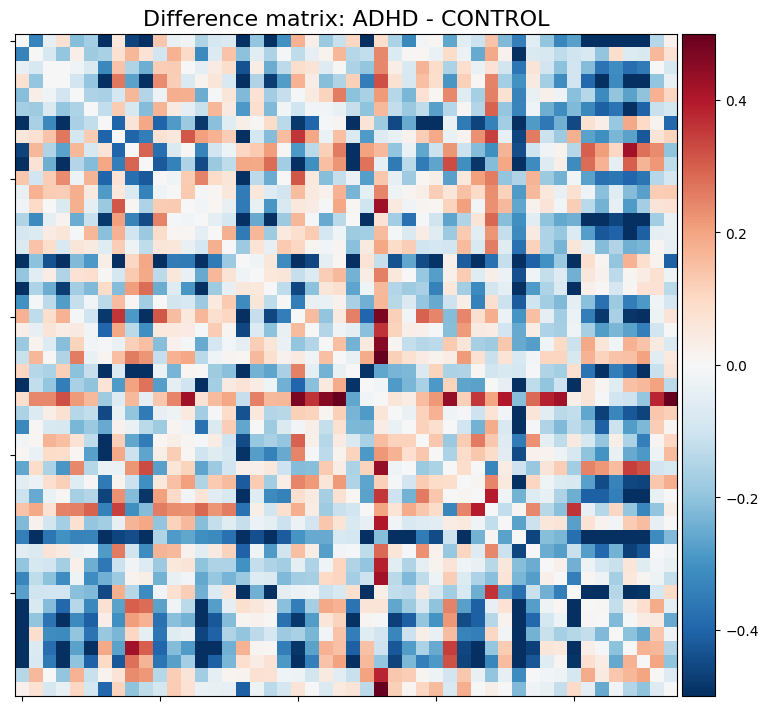

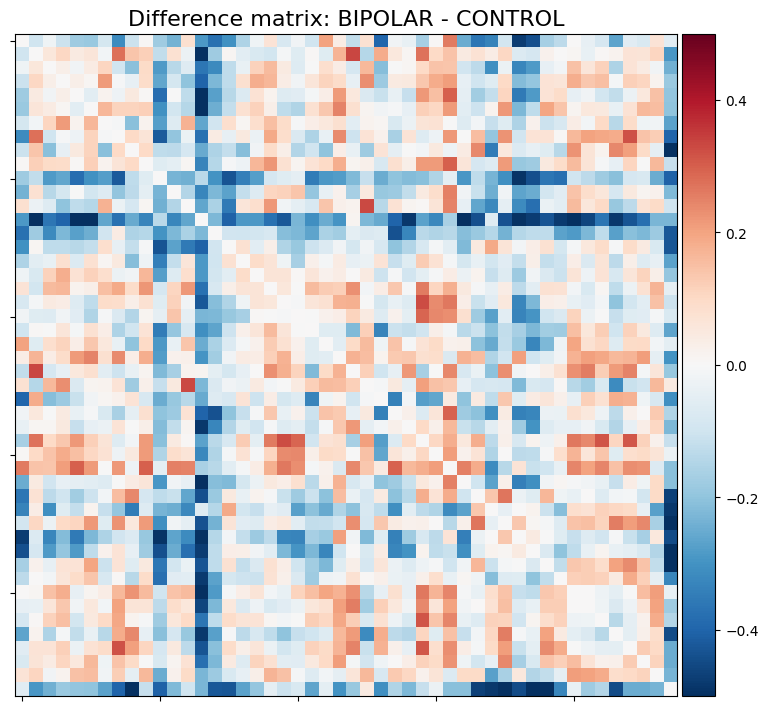

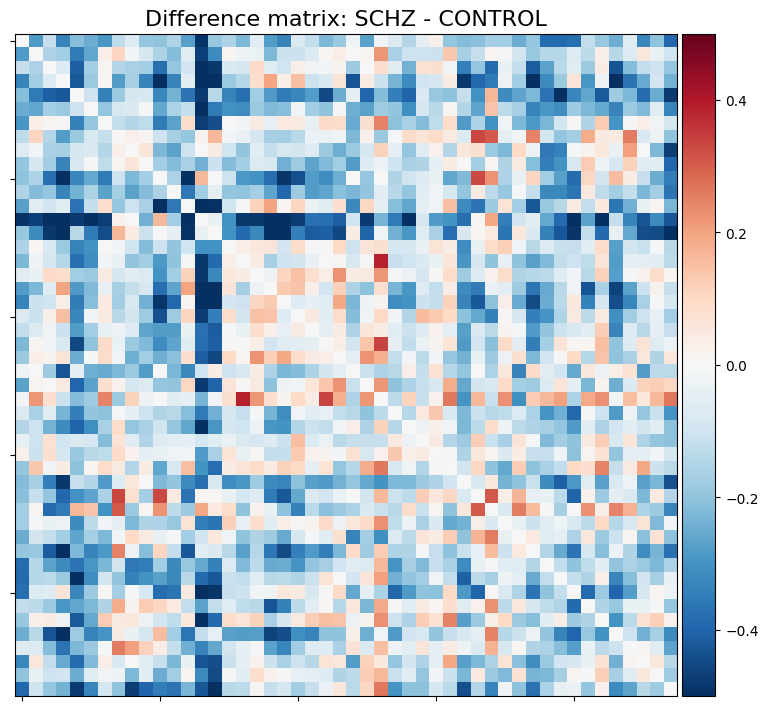

In [12]:
control_label = "CONTROL"

difference_matrices = {}

for diagnosis, matrix in group_average_matrices.items():
    if diagnosis == control_label:
        continue
    
    difference_matrices[diagnosis] = matrix - group_average_matrices[control_label]
    
    plotting.plot_matrix(
        difference_matrices[diagnosis],
        figure=(8, 7),
        vmin=-0.5,
        vmax=0.5,
        reorder=False,
        title=f"Difference matrix: {diagnosis} - {control_label}"
    )
    
    plt.show()

In [13]:
output_path = PROJECT_ROOT / "data" / "processed" / "group_connectivity_results.tsv"

results_df.to_csv(output_path, sep="\t", index=False)

print(f"Saved results to: {output_path}")

Saved results to: C:\Users\vi\psychiatric-brain-connectivity-analysis\data\processed\group_connectivity_results.tsv


## Summary

This notebook extended the connectivity pipeline from one subject to a small multi-group sample.

Completed steps:

- selected participants with resting-state fMRI;
- built subject-level functional connectivity matrices;
- computed group-average connectivity matrices;
- visualized diagnostic group differences against healthy controls.

Next step:

Increase the number of participants per group and add statistical testing of connectivity differences.